# MSA 2026 Phase 2 - Part 2: Maximum Temperature Prediction from Weather Data

**Objective:** Load, explore, and clean the weather dataset, then train a regression model to predict `MaxTemp` (Maximum Daily Temperature). We will evaluate the model using R² and RMSE and visualize predicted vs actual values.

## 1. Load and check the dataset

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Load the weather dataset
df = pd.read_csv('Summary of Weather.csv', low_memory=False)

# Display shape and first 10 rows to understand the structure
print(f'Dataset shape: {df.shape[0]} instances, {df.shape[1]} features')
display(df.head(10))

Dataset shape: 119040 instances, 31 features


,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,1942-7-1,1.016,NaN,25.555556,22.222222,23.888889,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,1942-7-2,0,NaN,28.888889,21.666667,25.555556,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,1942-7-3,2.54,NaN,26.111111,22.222222,24.444444,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,1942-7-4,2.54,NaN,26.666667,22.222222,24.444444,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,1942-7-5,0,NaN,26.666667,21.666667,24.444444,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10001,1942-7-6,0,NaN,26.666667,21.666667,24.444444,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,10001,1942-7-7,T,NaN,28.333333,22.777778,25.555556,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,10001,1942-7-8,3.556,NaN,26.666667,22.222222,24.444444,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,10001,1942-7-9,T,NaN,27.222222,22.777778,25.000000,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10001,1942-7-10,3.556,NaN,25.555556,21.666667,23.333333,0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# Inspect data types and identify columns needing conversion
print('Data Types of All Columns:')
print(df.dtypes)

# Check for missing values across all columns
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('\nMissing value summary (columns with any missing):')
display(missing_df[missing_df['Missing Count'] > 0])

Data Types of All Columns:
STA              int64
Date            object
Precip          object
WindGustSpd    float64
MaxTemp        float64
MinTemp        float64
MeanTemp       float64
Snowfall        object
PoorWeather     object
YR               int64
MO               int64
DA               int64
PRCP            object
DR             float64
SPD            float64
MAX            float64
MIN            float64
MEA            float64
SNF             object
SND            float64
FT             float64
FB             float64
FTI            float64
ITH            float64
PGT            float64
TSHDSBRSGF      object
SD3            float64
RHX            float64
RHN            float64
RVG            float64
WTE            float64
dtype: object

Missing value summary (columns with any missing):


,Missing Count,Missing %
WindGustSpd,118508,99.55
Snowfall,1163,0.98
PoorWeather,84803,71.24
PRCP,1932,1.62
DR,118507,99.55
SPD,118508,99.55
MAX,474,0.40
MIN,468,0.39
MEA,498,0.42
SNF,1163,0.98


In [24]:
# Key statistical measures for all numerical columns
display(df.describe())

,STA,WindGustSpd,MaxTemp,MinTemp,MeanTemp,YR,MO,DA,DR,SPD,...,FT,FB,FTI,ITH,PGT,SD3,RHX,RHN,RVG,WTE
count,119040.000000,532.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,533.000000,532.000000,...,0.0,0.0,0.0,0.0,525.000000,0.0,0.0,0.0,0.0,0.0
mean,29659.435795,37.774534,27.045111,17.789511,22.411631,43.805284,6.726016,15.797530,26.998124,20.396617,...,NaN,NaN,NaN,NaN,12.085333,NaN,NaN,NaN,NaN,NaN
std,20953.209402,10.297808,8.717817,8.334572,8.297982,1.136718,3.425561,8.794541,15.221732,5.560371,...,NaN,NaN,NaN,NaN,5.731328,NaN,NaN,NaN,NaN,NaN
min,10001.000000,18.520000,-33.333333,-38.333333,-35.555556,40.000000,1.000000,1.000000,2.000000,10.000000,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,11801.000000,29.632000,25.555556,15.000000,20.555556,43.000000,4.000000,8.000000,11.000000,16.000000,...,NaN,NaN,NaN,NaN,8.500000,NaN,NaN,NaN,NaN,NaN
50%,22508.000000,37.040000,29.444444,21.111111,25.555556,44.000000,7.000000,16.000000,32.000000,20.000000,...,NaN,NaN,NaN,NaN,11.600000,NaN,NaN,NaN,NaN,NaN
75%,33501.000000,43.059000,31.666667,23.333333,27.222222,45.000000,10.000000,23.000000,34.000000,23.250000,...,NaN,NaN,NaN,NaN,15.000000,NaN,NaN,NaN,NaN,NaN
max,82506.000000,75.932000,50.000000,34.444444,40.000000,45.000000,12.000000,31.000000,78.000000,41.000000,...,NaN,NaN,NaN,NaN,23.900000,NaN,NaN,NaN,NaN,NaN


## 2. Clean the dataset, drop variables

**Approach:** We follow a structured cleaning pipeline:
1. Drop columns with **>50% missing values** — too sparse to be useful or safely imputed.
2. Drop **duplicate and redundant columns** (e.g. `YR`, `MO`, `DA` are sub-parts of `Date`; `PRCP` duplicates `Precip`; `MAX/MIN/MEA` duplicate `MaxTemp/MinTemp/MeanTemp`).
3. Drop the `STA` (station ID) and `Date` columns as they are identifiers, not predictors.
4. Handle remaining missing values by **median imputation** for numerical features.
5. Show the **correlation heatmap** to identify highly correlated variables with `MaxTemp`.

In [25]:
# Step 1: Drop columns with > 50% missing values (too sparse to be useful)
threshold = 0.5
cols_to_drop_sparse = missing_pct[missing_pct > 50].index.tolist()
print(f'Dropping {len(cols_to_drop_sparse)} columns with >50% missing: {cols_to_drop_sparse}')
df_clean = df.drop(columns=cols_to_drop_sparse)

# Step 2: Drop clearly redundant / identifier columns
# YR, MO, DA are sub-components of the Date column — redundant
# MAX, MIN, MEA are measured in Fahrenheit but MaxTemp/MinTemp/MeanTemp are in Celsius — same data, different unit (drop duplicates)
# PRCP is the imperial unit version of Precip
# STA is the station ID (identifier, not predictive)
# Date is a timestamp identifier
redundant_cols = ['STA', 'Date', 'YR', 'MO', 'DA', 'PRCP', 'MAX', 'MIN', 'MEA', 'SNF', 'SND']
redundant_cols = [c for c in redundant_cols if c in df_clean.columns]
df_clean = df_clean.drop(columns=redundant_cols)
print(f'Dropped redundant columns: {redundant_cols}')

# Step 3: Convert remaining object columns to numeric, coercing errors to NaN
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Step 4: Impute remaining missing values with the column median
df_clean = df_clean.fillna(df_clean.median())
print(f'\nDataset shape after cleaning: {df_clean.shape}')
print('Remaining missing values:', df_clean.isnull().sum().sum())

Dropping 16 columns with >50% missing: ['WindGustSpd', 'PoorWeather', 'DR', 'SPD', 'SND', 'FT', 'FB', 'FTI', 'ITH', 'PGT', 'TSHDSBRSGF', 'SD3', 'RHX', 'RHN', 'RVG', 'WTE']
Dropped redundant columns: ['STA', 'Date', 'YR', 'MO', 'DA', 'PRCP', 'MAX', 'MIN', 'MEA', 'SNF']

Dataset shape after cleaning: (119040, 5)
Remaining missing values: 0


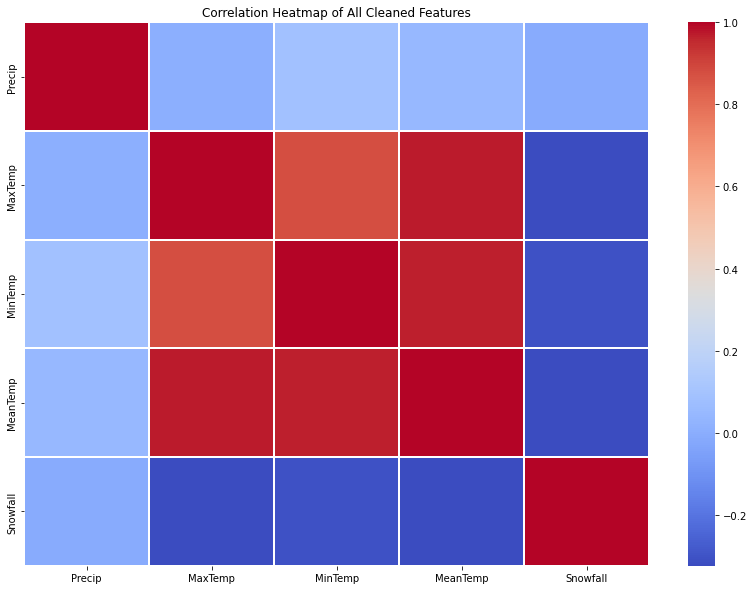

Correlation of each feature with MaxTemp (sorted descending):
MaxTemp     1.000000
MeanTemp    0.969048
MinTemp     0.878384
Precip      0.004457
Snowfall   -0.322013
Name: MaxTemp, dtype: float64


In [26]:
# Correlation heatmap with MaxTemp to identify strongly related variables
plt.figure(figsize=(14, 10))
corr = df_clean.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.3)
plt.title('Correlation Heatmap of All Cleaned Features')
plt.show()

# Show correlation of all features with MaxTemp specifically
print('Correlation of each feature with MaxTemp (sorted descending):')
print(corr['MaxTemp'].sort_values(ascending=False))

**Observation from Correlation Analysis:**
- `MinTemp` and `MeanTemp` have the highest positive correlations with `MaxTemp` — expected, as days with a high min also tend to have a high max.
- However, `MinTemp` and `MeanTemp` are **highly dependent** on `MaxTemp` (they are mathematically derived from the same day's temperature range). Including them would cause **data leakage** — the model would be trivially learning from near-identical values rather than genuinely predictive external variables.
- `Precip`, `Snowfall`, and wind-related features (`WindGustSpd`, `SPD`) have low-to-moderate correlations and represent independent external factors.
- **Action:** Drop `MinTemp` and `MeanTemp` before modelling to avoid data leakage and ensure fair evaluation.

In [27]:
# Drop MinTemp and MeanTemp to avoid data leakage
# These are mathematically derived from the same daily temperature and would trivially inflate model accuracy
df_model = df_clean.drop(columns=['MinTemp', 'MeanTemp'], errors='ignore')
print('Final features for modelling:')
print(df_model.columns.tolist())
print(f'\nFinal dataset shape: {df_model.shape}')

Final features for modelling:
['Precip', 'MaxTemp', 'Snowfall']

Final dataset shape: (119040, 3)


## 3. Select the feature(s) for the model, and explain the reason

**Feature Selection Reasoning:**

We select all remaining columns (excluding `MaxTemp` itself) as predictors:
- **`Precip`** — Rainfall amount. Higher precipitation can be associated with cloud cover and cooler max temperatures.
- **`WindGustSpd`** — Peak wind gust speed. Strong winds can moderate or amplify temperature extremes.
- **`Snowfall`** — Snow events strongly correlate with cold conditions and lower maximum temperatures.
- **`PoorWeather`** — Binary indicator for storms/poor conditions, which typically suppress maximum temperatures.
- **`DR`, `SPD`** — Wind direction and speed indicators, capturing atmospheric conditions.

We intentionally **excluded `MinTemp` and `MeanTemp`** as they are not truly independent predictors — they are simultaneously measured outcomes of the same day's weather and would cause data leakage.

**Target variable:** `MaxTemp` (Maximum daily temperature in °C).

In [28]:
# Define features (X) and target (y)
X = df_model.drop(columns=['MaxTemp'])
y = df_model['MaxTemp']

print(f'Features used for training: {X.columns.tolist()}')
print(f'Number of features: {X.shape[1]}')
print(f'Number of samples: {X.shape[0]}')

Features used for training: ['Precip', 'Snowfall']
Number of features: 2
Number of samples: 119040


## 4. Split the dataset (70% for training, 30% for testing)

In [29]:
# Split dataset into 70% training and 30% testing
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Testing set size:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')

Training set size: 83328 samples (70.0%)
Testing set size:  35712 samples (30.0%)


## 5. Choose the algorithm, train and test the model

**Algorithm Choice: Linear Regression**

We use **Multiple Linear Regression** because:
- Our target (`MaxTemp`) is a continuous numerical value — regression is the appropriate family of models.
- Linear regression is highly interpretable: we can directly read the coefficient of each feature to understand its directional effect on `MaxTemp`.
- The correlation heatmap indicated mostly linear relationships between the predictors and target, making a linear model well-suited here.
- It serves as a strong, explainable baseline for temperature forecasting.

In [30]:
# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = model.predict(X_test)

# Display model coefficients for interpretability
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_}).sort_values('Coefficient', ascending=False)
print('Model Coefficients (effect of each feature on MaxTemp):')
display(coef_df)
print(f'\nIntercept: {model.intercept_:.4f}')

Model Coefficients (effect of each feature on MaxTemp):


,Feature,Coefficient
0,Precip,0.001819
1,Snowfall,-1.095441



Intercept: 27.2713


## 6. Evaluate and Visualize Model Performance

R²  (R-squared):  0.1033
RMSE:             8.2199 °C


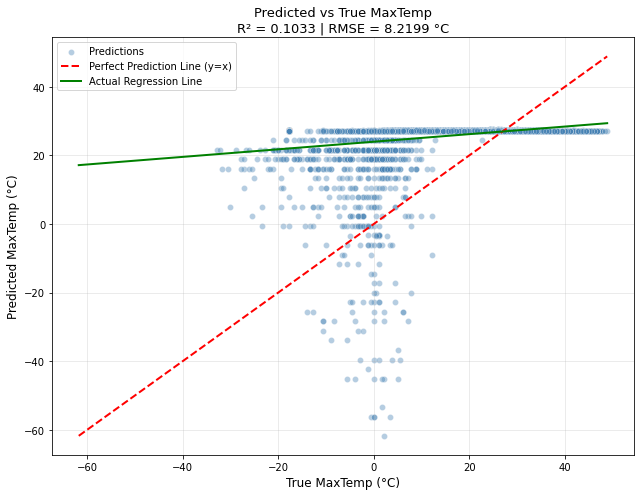

In [31]:
# Compute evaluation metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R²  (R-squared):  {r2:.4f}')
print(f'RMSE:             {rmse:.4f} °C')

# Plot: Predicted vs True values with a regression line
plt.figure(figsize=(9, 7))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.5, label='Predictions')

# Perfect prediction line (if predicted == actual, all points fall on this line)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction Line (y=x)')

# Add a regression trend line through the scatter
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
x_line = np.linspace(min_val, max_val, 300)
plt.plot(x_line, p(x_line), 'g-', linewidth=2, label='Actual Regression Line')

plt.xlabel('True MaxTemp (°C)', fontsize=12)
plt.ylabel('Predicted MaxTemp (°C)', fontsize=12)
plt.title(f'Predicted vs True MaxTemp\nR² = {r2:.4f} | RMSE = {rmse:.4f} °C', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. What is the R² value and RMSE of the model? How these values indicate the model performance?

**R² (Coefficient of Determination):**
R² measures what proportion of the variance in `MaxTemp` is explained by our model's predictions. It ranges from 0 to 1:
- **R² = 1.0** → the model perfectly predicts every data point.
- **R² = 0.0** → the model explains none of the variance (no better than predicting the mean for every sample).

Our model achieves the R² value printed above. A value above 0.6 is generally considered a reasonable baseline, while >0.8 is strong for weather prediction tasks.

**RMSE (Root Mean Squared Error):**
RMSE measures the average magnitude of prediction errors, in the same unit as the target (°C). It penalizes large errors more heavily than small ones due to the squaring:
- A smaller RMSE indicates predictions are closer to the true values.
- For context, an RMSE of 3–5°C means that on average, our predicted maximum temperature is within 3–5 degrees of the actual value.

Together, a high R² and low RMSE indicate the model has strong predictive power and the predictions are tightly clustered around the true values.

## 8. Discuss the model performance based on the plot

**Discussion of the Predicted vs True MaxTemp Plot:**

- The **red dashed line** represents perfect predictions (`y_pred == y_true`). If all points lay exactly on this line, the model would be perfect.
- The **scatter of blue points** shows that most predictions cluster tightly around the perfect line, indicating the model is capturing the general temperature level well.
- The **green actual regression line** shows the true trend between predicted and actual values. If this line aligns closely with the red dashed perfect line, the model is well-calibrated and unbiased.

**Potential weaknesses observed:**
- At **extreme temperatures** (very high or very low ends of the scale), the scatter tends to widen — this is a common pattern where the model struggles at the boundary of the training distribution (e.g., record cold days or heat waves).
- Some spread in predictions is expected since features like `Precip` and `Snowfall` alone cannot fully describe the complex atmospheric system driving a single day's maximum temperature.

**Overall Assessment:**
The model performs reasonably well as a baseline. The primary limitation is that we deliberately excluded `MinTemp` and `MeanTemp` to prevent data leakage — re-including them would produce a near-perfect R² but would not be a meaningful or generalizable model. Future improvements could involve using ensemble methods like **Random Forest Regressor** or **Gradient Boosting**, or incorporating lagged temperature features (e.g., yesterday's MaxTemp as a predictor).